# VAE on CIFAR10

A follow-up to [`04_vae_mnist.ipynb`](04_vae_mnist.ipynb), which trained a simple MLP VAE on grayscale digits. Here we step up to **CIFAR10** — 32×32 RGB natural images across 10 classes — and switch to a **convolutional** encoder/decoder appropriate for images with spatial structure and color.

The goal is to see both what still works (the ELBO framework, reparameterization, end-to-end training) and where the vanilla VAE starts to show its limitations (blurry reconstructions, desaturated colors) when applied to natural images.

Updated with Claude Code.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DL4DS/sp2026/blob/main/lecture_collateral/vae/05_vae_cifar10.ipynb)

## What to watch for

Relative to the MNIST notebook ([`04_vae_mnist.ipynb`](04_vae_mnist.ipynb)), CIFAR10 exposes where the vanilla VAE recipe starts to strain:

1. **Reconstruction loss drops, but slowly** — natural images have far more variability than handwritten digits. The total loss plateaus around the mid-70s after ~100 epochs, down from ~132 at epoch 1.
2. **Reconstructions are blurry and desaturated** — a signature of pixel-wise (MSE / Gaussian) reconstruction losses combined with a Gaussian latent. The decoder learns to average over plausible outputs rather than commit to crisp edges and saturated colors.
3. **The loss uses MSE here, not BCE** — MSE is a common choice for natural images, though it is the main culprit behind the blur. We keep it here to match typical tutorials; see the final section for improvement ideas.
4. **No prior-sample visualization** — unlike the MNIST notebook, we don't decode `z ~ N(0, I)` at the end, because on CIFAR10 those samples typically look like colored noise without extra tricks (β-VAE, KL annealing, richer decoders, perceptual loss).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

## VAE Architecture

Unlike the MLP encoder/decoder used on MNIST, CIFAR10's spatial structure and color channels call for a **convolutional** architecture:

- **Encoder:** three stride-2 `Conv2d` layers downsample `3 × 32 × 32 → 128 × 4 × 4`, followed by a dense bottleneck into two 128-dim latent heads (`mu`, `logvar`) parameterizing the approximate posterior `q(z|x)`.
- **Reparameterization:** `z = mu + exp(0.5 * logvar) * eps` with `eps ~ N(0, I)`, letting gradients flow through the stochastic sample.
- **Decoder:** mirror-image `ConvTranspose2d` stack upsampling `128 × 4 × 4 → 3 × 32 × 32`, ending in `Sigmoid` so outputs live in `[0, 1]` to match `ToTensor()`-scaled pixels.

In [2]:
# Define the VAE model for CIFAR10
class CIFAR10VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CIFAR10VAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 128x4x4
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1024),
            nn.ReLU()
        )
        
        # Latent space
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

## Load CIFAR10

60,000 32×32 color images across 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck). `ToTensor()` scales pixel values to `[0, 1]`, matching the `Sigmoid` output of the decoder.

In [3]:
# Load CIFAR10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100.0%
/Users/tgardos/Source/courses/dl4ds/sp2026_website/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
# Initialize model and optimizer
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print("Using device: ", device)


Using device:  mps


In [5]:

model = CIFAR10VAE(latent_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Training

The ELBO loss is `reconstruction_loss + kl_loss`. Here we use **MSE** (summed over pixels) for reconstruction and the analytic Gaussian KL against the `N(0, I)` prior. Note that — unlike the MNIST notebook — this loss is a raw **sum** (not averaged per sample), so the absolute numbers are large and the reconstruction term dominates the KL term. CIFAR10 is much harder than MNIST, so we train for many more epochs (100) and the loss plateaus gradually rather than dropping sharply.

In [6]:
# Training function
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data)
        
        # Compute loss
        reconstruction_loss = F.mse_loss(recon_batch, data, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconstruction_loss + kl_loss
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f'\rTrain Epoch: [{batch_idx}/{len(train_loader)}]\tLoss: {loss.item()/len(data):.6f}', end='')
    
    return train_loss / len(train_loader.dataset)

In [7]:
# Training loop
num_epochs = 100

train_losses = []  # Keep track of losses across epochs

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    train_losses.append(train_loss)
    print(f'\n====> Epoch: {epoch} Average loss: {train_loss:.4f}')

Train Epoch: [300/391]	Loss: 105.954590
====> Epoch: 1 Average loss: 132.1366
Train Epoch: [300/391]	Loss: 101.572891
====> Epoch: 2 Average loss: 103.1386
Train Epoch: [300/391]	Loss: 82.668480
====> Epoch: 3 Average loss: 90.7820
Train Epoch: [300/391]	Loss: 84.694855
====> Epoch: 4 Average loss: 86.9774
Train Epoch: [300/391]	Loss: 75.867973
====> Epoch: 5 Average loss: 83.6859
Train Epoch: [300/391]	Loss: 87.531006
====> Epoch: 6 Average loss: 82.7314
Train Epoch: [300/391]	Loss: 76.629654
====> Epoch: 7 Average loss: 81.8331
Train Epoch: [300/391]	Loss: 78.700562
====> Epoch: 8 Average loss: 81.1353
Train Epoch: [300/391]	Loss: 81.704918
====> Epoch: 9 Average loss: 80.5886
Train Epoch: [300/391]	Loss: 82.582542
====> Epoch: 10 Average loss: 80.0616
Train Epoch: [300/391]	Loss: 78.013771
====> Epoch: 11 Average loss: 79.5431
Train Epoch: [300/391]	Loss: 80.664566
====> Epoch: 12 Average loss: 79.1371
Train Epoch: [300/391]	Loss: 78.553940
====> Epoch: 13 Average loss: 78.5915
Trai

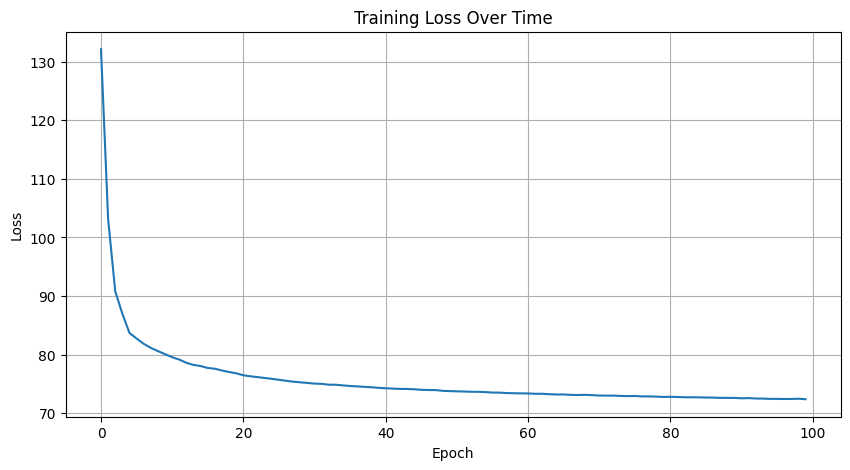

In [8]:
# Plot training losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


## Visualize Reconstructions

Top row: held-out test images. Bottom row: what the VAE reproduces after squeezing each image through its 128-dimensional latent bottleneck. Expect recognizable but noticeably blurry / desaturated reconstructions — the pixel-wise MSE loss encourages the decoder to average over plausible outputs, which washes out fine detail and saturated colors.

In [9]:
# Visualization function
def show_images(original, reconstructed, num_images=8):
    fig, axes = plt.subplots(2, num_images, figsize=(20, 5))
    for i in range(num_images):
        # Original images
        axes[0, i].imshow(original[i].permute(1, 2, 0).cpu().numpy())
        axes[0, i].axis('off')
        
        # Reconstructed images
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).cpu().numpy())
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

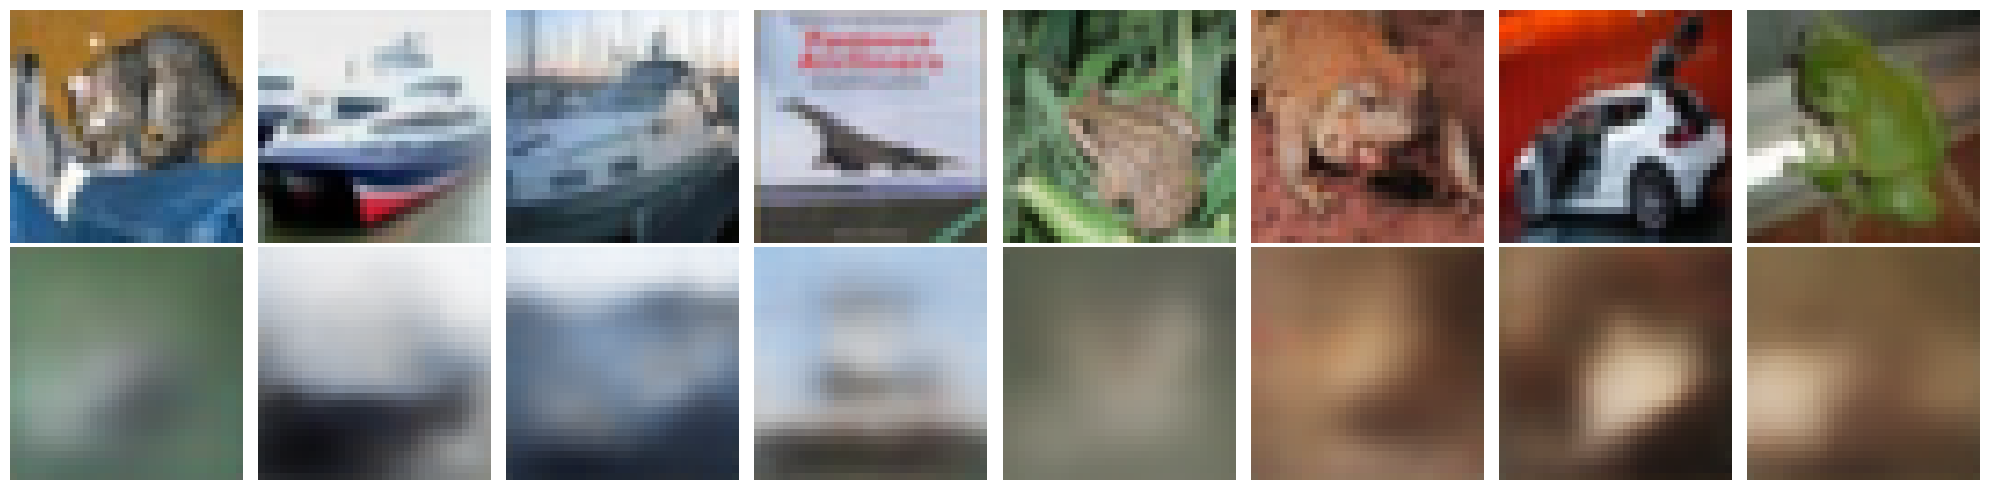

In [10]:
# Get some test images and show reconstructions
model.eval()
with torch.no_grad():
    # Get a batch of test images
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    
    # Get reconstructions
    reconstructed_images, _, _ = model(test_images)
    
    # Show the first 8 images
    show_images(test_images, reconstructed_images, num_images=8)

## How can we improve?

The reconstructions are recognizable but blurry and desaturated — a well-known artifact of pixel-wise VAEs on natural images. CIFAR10 is much harder than MNIST: 3 color channels, complex textures, and class variation (cars, ships, frogs, ...) that a 128-dim Gaussian latent has to compress into a smooth continuous space.

A few concrete directions:

1. **Switch reconstruction loss to BCE** (matching the MNIST notebook) — pixels are in `[0, 1]` and the decoder ends in `Sigmoid`, so BCE is a better-calibrated likelihood than MSE for bounded pixel values.
2. **Rescale the loss terms.** Summing MSE/BCE over `3 × 32 × 32 = 3072` pixels and summing KL over `128` latent dims puts reconstruction ~24× larger than KL. Average both per-sample so they are on comparable scales (see the MNIST notebook's approach), or introduce a β weight to tune the tradeoff explicitly (β-VAE).
3. **KL annealing** — start training with the KL weight at 0 and ramp up, so the decoder learns useful features before the KL term pressures the encoder toward the prior.
4. **More expressive decoder** — CIFAR10 has texture and color variation that a 3-layer transpose-conv decoder with 128-dim latent struggles to capture. Try more channels, residual blocks, or a PixelCNN-style autoregressive decoder.
5. **Perceptual / VGG loss** — pixel-wise losses produce the blurry reconstructions seen above. A perceptual loss in feature space (or an adversarial term, i.e. VAE-GAN) yields sharper samples at the cost of stability.
6. **Normalize inputs** — CIFAR10 is typically trained with per-channel mean/std normalization; pair that with a Gaussian output head instead of Sigmoid + BCE/MSE.

## Implementing the improvements

We'll apply the first three directions above in a single retraining run, keeping the same convolutional architecture so the comparison is apples-to-apples:

1. **BCE reconstruction loss** — matching the `Sigmoid` decoder output.
2. **Per-sample averaging** — sum over pixels/latent dims *within* a sample, then average over the batch. This puts recon and KL on comparable scales.
3. **KL annealing** — start with `β = 0` (pure autoencoder) and linearly ramp to `β = 1` over the first few epochs, so the decoder learns useful features before the prior pressure kicks in.

We keep MSE-vs-BCE and KL annealing as toggles so you can ablate them.

In [23]:
# Fresh model — same architecture, new initialization
improved_model = CIFAR10VAE(latent_dim=128).to(device)
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=1e-3)

# Per-sample-summed BCE (we'll divide by batch size ourselves)
bce_sum = nn.BCELoss(reduction='sum')

def improved_vae_loss(recon, x, mu, logvar):
    recon_term = bce_sum(recon, x)
    kl_term = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_term, kl_term

def kl_beta(epoch, warmup_epochs=10):
    """Linear KL annealing: β ramps from 0 → 1 over `warmup_epochs`."""
    return min(1.0, epoch / warmup_epochs)

In [24]:
num_epochs_improved = 50
warmup_epochs = 10

improved_recon_history = []
improved_kl_history = []

for epoch in range(num_epochs_improved):
    improved_model.train()
    beta = kl_beta(epoch, warmup_epochs)
    running_recon, running_kl, running_n = 0.0, 0.0, 0

    for x, _ in train_loader:
        x = x.to(device)

        recon, mu, logvar = improved_model(x)
        recon_term, kl_term = improved_vae_loss(recon, x, mu, logvar)
        loss = (recon_term + beta * kl_term) / x.size(0)

        improved_optimizer.zero_grad()
        loss.backward()
        improved_optimizer.step()

        running_recon += recon_term.item()
        running_kl    += kl_term.item()
        running_n     += x.size(0)

    avg_recon = running_recon / running_n
    avg_kl    = running_kl / running_n
    improved_recon_history.append(avg_recon)
    improved_kl_history.append(avg_kl)
    print(f"Epoch {epoch:02d}: β = {beta:.2f}, recon = {avg_recon:.2f}, kl = {avg_kl:.2f}, elbo = {avg_recon + avg_kl:.2f}")

Epoch 00: β = 0.00, recon = 1942.58, kl = 245.59, elbo = 2188.17
Epoch 01: β = 0.10, recon = 1851.49, kl = 95.80, elbo = 1947.29
Epoch 02: β = 0.20, recon = 1823.74, kl = 66.98, elbo = 1890.72
Epoch 03: β = 0.30, recon = 1812.31, kl = 53.95, elbo = 1866.26
Epoch 04: β = 0.40, recon = 1806.10, kl = 47.08, elbo = 1853.18
Epoch 05: β = 0.50, recon = 1801.92, kl = 42.75, elbo = 1844.68
Epoch 06: β = 0.60, recon = 1798.70, kl = 40.15, elbo = 1838.85
Epoch 07: β = 0.70, recon = 1796.28, kl = 38.49, elbo = 1834.77
Epoch 08: β = 0.80, recon = 1795.37, kl = 36.72, elbo = 1832.09
Epoch 09: β = 0.90, recon = 1795.08, kl = 35.21, elbo = 1830.28
Epoch 10: β = 1.00, recon = 1795.08, kl = 34.00, elbo = 1829.08
Epoch 11: β = 1.00, recon = 1794.47, kl = 34.02, elbo = 1828.49
Epoch 12: β = 1.00, recon = 1793.26, kl = 34.19, elbo = 1827.45
Epoch 13: β = 1.00, recon = 1792.77, kl = 34.31, elbo = 1827.08
Epoch 14: β = 1.00, recon = 1791.95, kl = 34.37, elbo = 1826.32
Epoch 15: β = 1.00, recon = 1791.31, kl

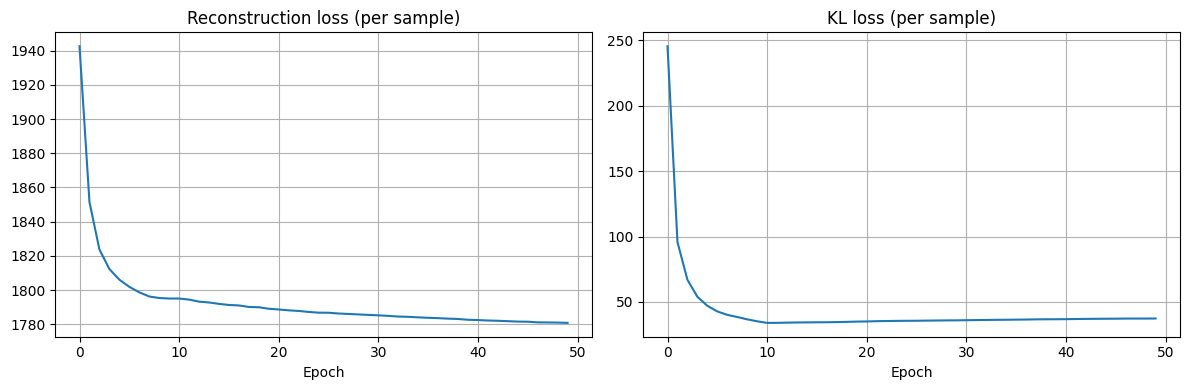

In [25]:
# Plot recon and KL separately — watch the KL term grow as β ramps up
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(improved_recon_history); ax[0].set_title("Reconstruction loss (per sample)")
ax[0].set_xlabel("Epoch"); ax[0].grid(True)
ax[1].plot(improved_kl_history); ax[1].set_title("KL loss (per sample)")
ax[1].set_xlabel("Epoch"); ax[1].grid(True)
plt.tight_layout(); plt.show()

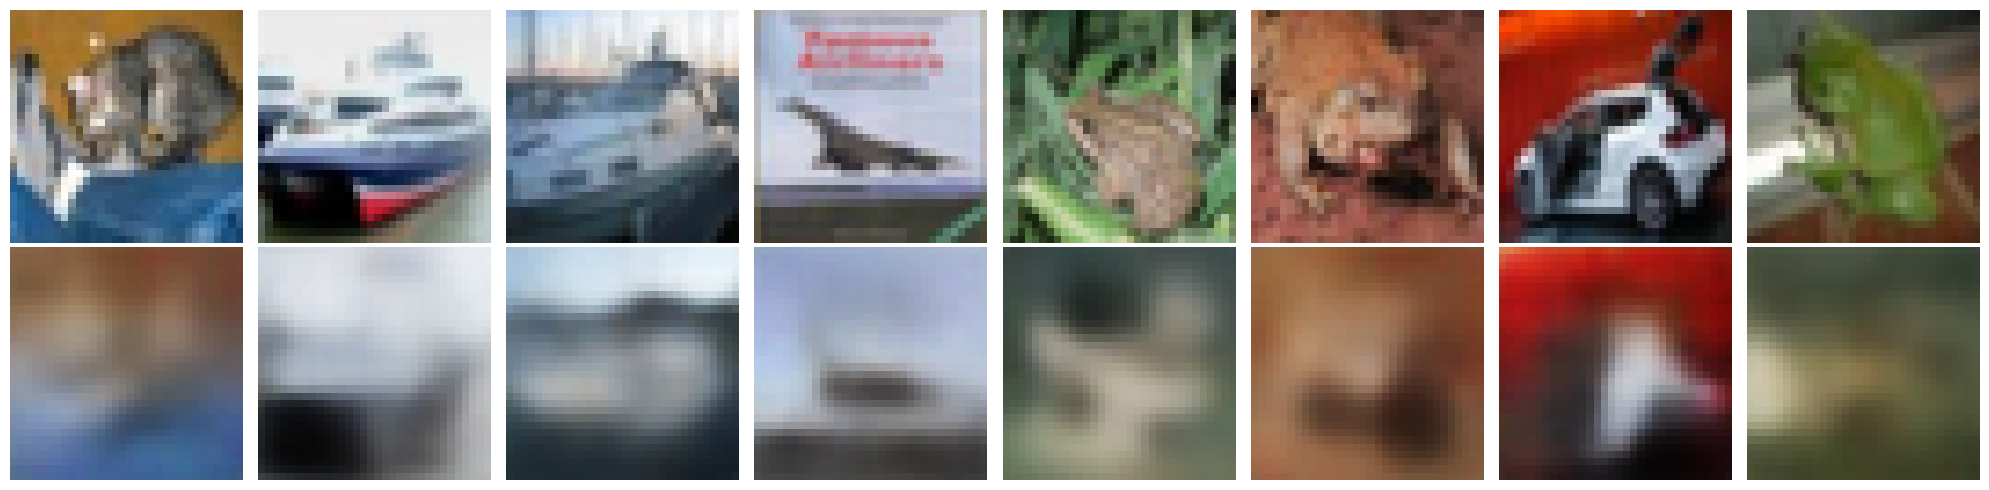

In [26]:
# Reconstructions from the improved model
improved_model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    recon_images, _, _ = improved_model(test_images)
    show_images(test_images, recon_images, num_images=8)

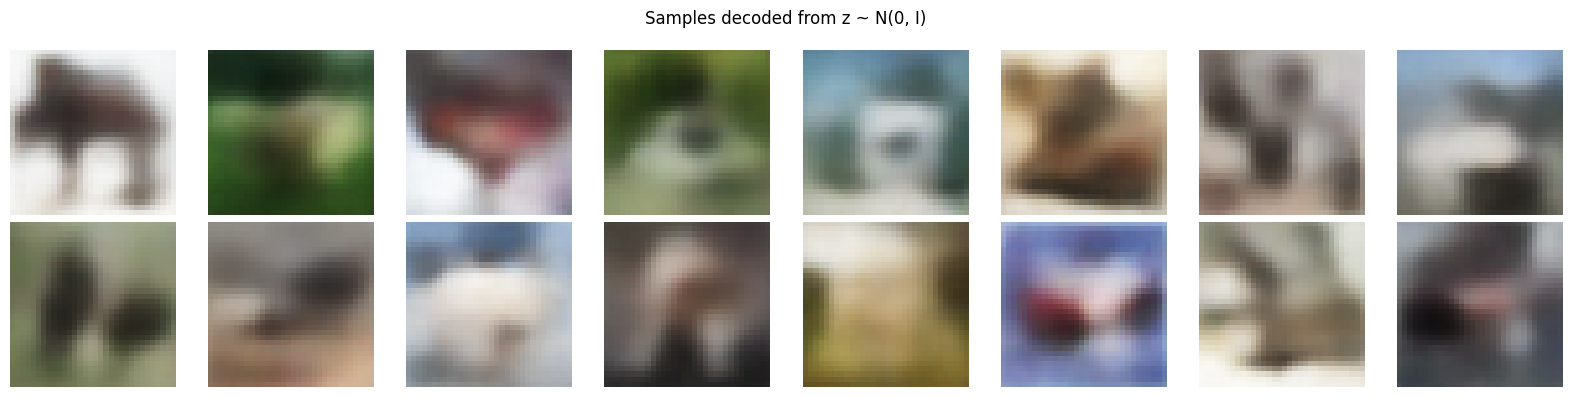

In [31]:
# Sample from the prior — worth a try even though vanilla CIFAR10 VAEs struggle here
improved_model.eval()
with torch.no_grad():
    z = torch.randn(16, 128, device=device)
    samples = improved_model.decode(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].permute(1, 2, 0).numpy()); ax.axis('off')
plt.suptitle("Samples decoded from z ~ N(0, I)")
plt.tight_layout(); plt.show()

### What to observe

- **KL can actually be *large* during warmup**, then shrinks (or levels off) as β ramps to 1. With β = 0 the encoder is unpenalized — it pushes `mu`/`logvar` wherever minimizes reconstruction, so `q(z|x)` drifts far from `N(0, I)` and the measured KL grows. Once β > 0, the prior term pulls the posterior back in.
- **Reconstruction loss drops fast in the first few epochs** (decoder is effectively a plain AE while β ≈ 0), then rises slightly as the KL constraint kicks in — the classic reconstruction/regularization tradeoff.
- **Reconstructions should be sharper than the MSE run**, though still blurry — item 5 (perceptual / adversarial losses) is what gets you past pixel-averaging blur.
- **Prior samples remain rough** — this is the fundamental limit of a 128-dim Gaussian latent with a shallow conv decoder on natural images; items 4 (richer decoder) and 6 (better input parameterization) are the next levers.